In [26]:
import pandas as pd

# 1. Load the dataset (Make sure the filename matches what you downloaded)
df = pd.read_csv('E Commerce Customer Insights and Churn Dataset.csv')



In [27]:
# 2. Drop rows where CustomerID is missing
# In RFM, if we don't know who the customer is, we can't track them.
df = df.dropna(subset=['customer_id'])

# 3. Remove duplicate entries
# This prevents inflating the "Frequency" and "Monetary" metrics.
df = df.drop_duplicates()

# 4. Convert OrderDate to Datetime format
# This is CRITICAL for calculating 'Recency' later.
df['order_date'] = pd.to_datetime(df['order_date'])

# 5. Fix numeric columns (Optional but recommended)
# Ensure Quantity and Price are positive numbers
df = df[df['quantity'] > 0]
df = df[df['unit_price'] > 0]

# 6. Create a 'TotalSum' column
# This simplifies your 'Monetary' calculation in the next step.
df['TotalSum'] = df['quantity'] * df['unit_price']

# Display the first 5 rows to verify
print("Cleaning Complete! Here is the cleaned data:")
print(df.head())

# Show summary of missing values to prove to the client the data is clean
print("\nMissing Values Count:")
print(df.isnull().sum())

Cleaning Complete! Here is the cleaned data:
  order_id customer_id  age product_id   country signup_date  \
0  ORD5000    CUST1000   39    PROD200    Canada    1/7/2021   
1  ORD5001    CUST1001   61    PROD201       USA  10/19/2020   
2  ORD5002    CUST1002   26    PROD202  Pakistan   6/10/2023   
3  ORD5003    CUST1003   54    PROD203     India   7/30/2023   
4  ORD5004    CUST1004   50    PROD204     India   12/9/2020   

  last_purchase_date  cancellations_count subscription_status order_date  \
0          2/21/2023                    0              active 2024-08-20   
1          12/8/2021                    0              active 2025-07-17   
2           9/4/2023                    3           cancelled 2025-03-12   
3          2/20/2024                    4              paused 2024-09-19   
4          9/14/2024                    0              active 2024-08-08   

   unit_price  quantity  purchase_frequency preferred_category  product_name  \
0       78.21         5          

In [28]:
import datetime as dt

# 1. Set a "Snapshot Date" 
# We act as if we are analyzing this today. 
# We take the day after the last transaction in the dataset as our 'today'.
snapshot_date = df['order_date'].max() + dt.timedelta(days=1)

# 2. Group by CustomerID and calculate R, F, and M
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'count',                                  # Frequency
    'TotalSum': 'sum'                                     # Monetary
})

# 3. Rename the columns for clarity
rfm.rename(columns={
    'order_date': 'Recency',
    'order_id': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

# 4. Display the results
print("RFM Table Created Successfully!")
print(rfm.head())

RFM Table Created Successfully!
             Recency  Frequency  Monetary
customer_id                              
CUST1000         366          1    391.05
CUST1001          35          1    512.16
CUST1002         162          1   1208.28
CUST1003         336          1    338.64
CUST1004         378          1    438.62


In [29]:
# Create labels for our scores (1 is lowest, 5 is highest)
r_labels = range(5, 0, -1) # For Recency, a smaller number of days is better (5)
f_labels = range(1, 6)
m_labels = range(1, 6)

# Assign these labels to 5 equal percentile groups
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

# Concatenate RFM scores to create an RFM_Segment (e.g., "555" or "111")
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

print("\nFinal Scored Table:")
print(rfm.head())


Final Scored Table:
             Recency  Frequency  Monetary  R  F  M  RFM_Score
customer_id                                                  
CUST1000         366          1    391.05  4  1  1          6
CUST1001          35          1    512.16  5  1  2          8
CUST1002         162          1   1208.28  5  1  3          9
CUST1003         336          1    338.64  4  1  1          6
CUST1004         378          1    438.62  4  1  2          7


                    Recency Frequency Monetary      
                       mean      mean     mean count
Segment                                             
At Risk               979.4       1.0    576.4   281
Champions             262.3       1.0   1638.6   159
Lost                 1262.5       1.0    278.5    18
Loyal Customers       460.8       1.0   1233.5   687
Potential Loyalists   730.4       1.0    908.5   855


C:\Users\user\AppData\Local\Temp\ipykernel_19288\3923878475.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viz_data = rfm.groupby(['R', 'F']).size().unstack()


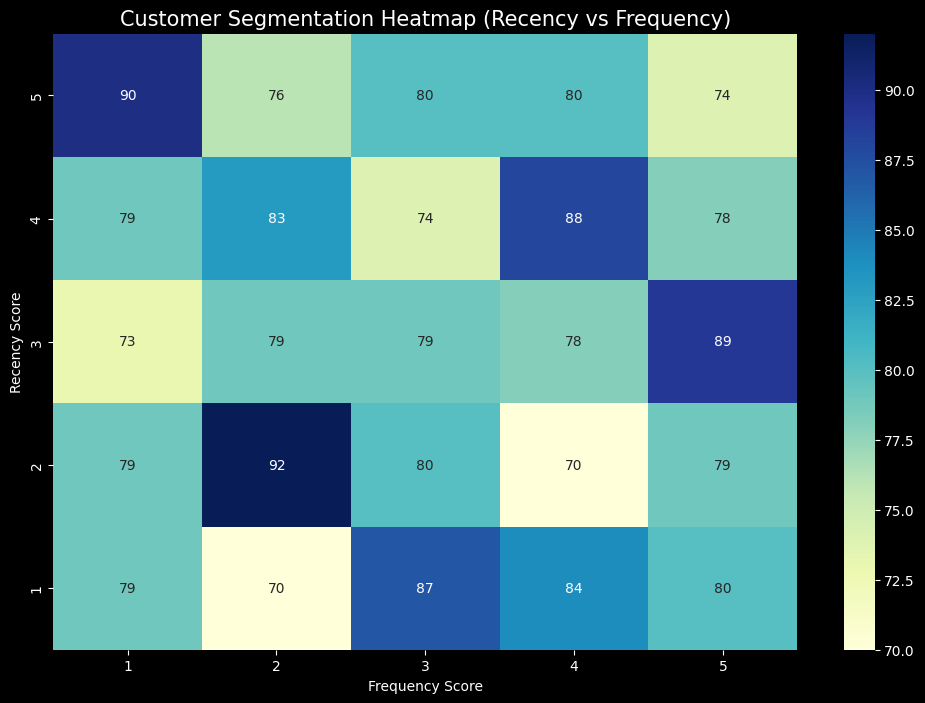

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the segments based on RFM Score
# We create a function to give each customer a "Label"
def segment_me(df):
    if df['RFM_Score'] >= 13:
        return 'Champions'
    elif (df['RFM_Score'] >= 10) and (df['RFM_Score'] < 13):
        return 'Loyal Customers'
    elif (df['RFM_Score'] >= 7) and (df['RFM_Score'] < 10):
        return 'Potential Loyalists'
    elif (df['RFM_Score'] >= 4) and (df['RFM_Score'] < 7):
        return 'At Risk'
    else:
        return 'Lost'

# Apply the function
rfm['Segment'] = rfm.apply(segment_me, axis=1)

# 2. Prepare data for the Heatmap
# We calculate the average Recency, Frequency, and Monetary for each segment
rfm_level_agg = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print(rfm_level_agg)

# 3. The "Fiverr Money Shot" - Visualizing the Segments
plt.figure(figsize=(12, 8))
plt.style.use('dark_background') # Makes the chart look high-tech

# Create a pivot table for the heatmap
viz_data = rfm.groupby(['R', 'F']).size().unstack()

sns.heatmap(viz_data, annot=True, cmap="YlGnBu", fmt='g')
plt.title('Customer Segmentation Heatmap (Recency vs Frequency)', fontsize=15)
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.show()

--- AI Prediction Report ---
              precision    recall  f1-score   support

           0       0.73      0.92      0.81       289
           1       0.33      0.10      0.15       111

    accuracy                           0.69       400
   macro avg       0.53      0.51      0.48       400
weighted avg       0.62      0.69      0.63       400



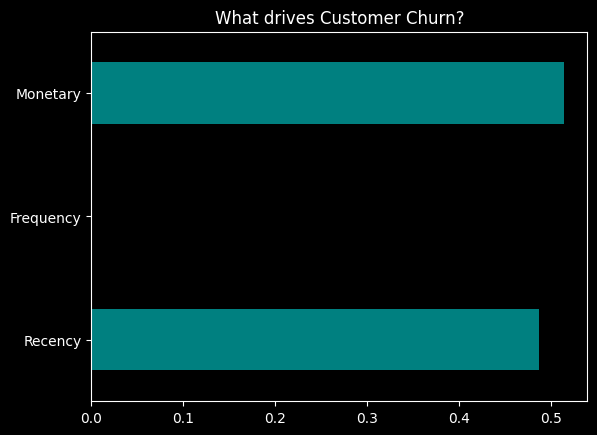

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Prepare the Features (X) and Target (y)
# We use the RFM scores to predict the subscription_status
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = df.groupby('customer_id')['subscription_status'].first() 

# Convert target to binary: 1 for 'cancelled', 0 for 'active/paused'
y = y.apply(lambda x: 1 if x == 'cancelled' else 0)

# 2. Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Accuracy Check
predictions = model.predict(X_test)
print("--- AI Prediction Report ---")
print(classification_report(y_test, predictions))

# 5. Feature Importance - What matters most?
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.plot(kind='barh', color='teal')
plt.title('What drives Customer Churn?')
plt.show()